# ***Robinhood Product Case Study***
***NLP Analysis of 21,000+ Google Play Reviews (2024-2026)***

****Question***: Are Robinhood's new products (Gold, banking, credit card) changing what users complain about, or are the same problems persisting regardless of feature additions?*

****Tools***: Python, Google Play Scraper, VADER Sentiment, LDA Topic Modeling, Matplotlib*

---

### 1. Imports and Setup

In [1]:
# Main data libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Data collection
from google_play_scraper import reviews, Sort

# Visualization
import matplotlib.pyplot as plt
import matplotlib as mpl
from wordcloud import WordCloud

# NLP and sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Topic modeling
import gensim
from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS

print('All libraries loaded successfully')

All libraries loaded successfully


### 2. Color Theme and Chart Styling

In [2]:
# Robinhood-inspired color palette
RH_GREEN = '#00C805'       
RH_DARK = '#1a1a1a'
RH_GRAY = '#4a4a4a'
RH_RED = '#FF5000'
RH_LIGHT = '#f5f5f5'
RH_GREEN_DARK = '#009604'

# Applying these settings globally so every chart inherits them automatically
plt.rcParams.update({
    'figure.facecolor': RH_LIGHT,
    'axes.facecolor': RH_LIGHT,
    'axes.edgecolor': RH_GRAY,
    'axes.labelcolor': RH_DARK,
    'axes.titlecolor': RH_DARK,
    'xtick.color': RH_GRAY,
    'ytick.color': RH_GRAY,
    'text.color': RH_DARK,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.titlesize': 14,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Color theme applied')

Color theme applied


### 3. Data Collection
*Pulling Robinhood reviews from Google Play Store using the `google-play-scraper` library.*
*We use the App Store because it gives us timestamped reviews we can track over time.*

> **Note:** Apple App Store API returned 401 unauthorized errors, so Google Play is our primary source. iOS and Android user behavior may differ slightly.

In [3]:
# Pulling reviews in batches of 3,000 using a continuation token
# The continuation_token tells the scraper where it left off each round so we can keep pulling older and older reviews without starting over

all_reviews = []
continuation_token = None

for i in range(7):
    result, continuation_token = reviews(
        'com.robinhood.android',  # Robinhood's unique package ID on Google Play
        lang='en',                # English reviews only
        country='us',             # US store only
        sort=Sort.NEWEST,         # Pulling newest first so we can track over time
        count=3000,               # Pulling 3,000 reviews per round
        continuation_token=continuation_token
    )
    all_reviews.extend(result)
    
    # Printing progress after each round
    print(f"Round {i+1}: {len(all_reviews):,} total reviews | Earliest: {min(r['at'] for r in result)}")
    
    # Stopping early if there are no more reviews to pull
    if not continuation_token:
        break

print(f'\nDone. Total reviews collected: {len(all_reviews):,}')

Round 1: 3,000 total reviews | Earliest: 2026-02-16 02:54:46
Round 2: 6,000 total reviews | Earliest: 2025-06-22 11:52:25
Round 3: 9,000 total reviews | Earliest: 2025-03-15 01:34:46
Round 4: 12,000 total reviews | Earliest: 2025-01-01 10:59:19
Round 5: 15,000 total reviews | Earliest: 2024-11-01 10:07:58
Round 6: 18,000 total reviews | Earliest: 2024-07-03 01:17:14
Round 7: 21,000 total reviews | Earliest: 2024-03-14 16:31:59

Done. Total reviews collected: 21,000


In [4]:
# Converting the list of review dictionaries into a pandas DataFrame
df = pd.DataFrame(all_reviews)

# Removing duplicate reviews
df = df.drop_duplicates(subset='reviewId')

# Converting the 'at' column to a proper datetime format
df['at'] = pd.to_datetime(df['at'])

df.to_csv('../data/robinhood_reviews_raw.csv', index=False)

print(f'Total unique reviews saved: {len(df):,}')
print(f'Date range: {df["at"].min().date()} to {df["at"].max().date()}')
print(f'Columns: {df.columns.tolist()}')

Total unique reviews saved: 21,000
Date range: 2024-03-14 to 2026-06-08
Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


### 4. Exploratory Analysis

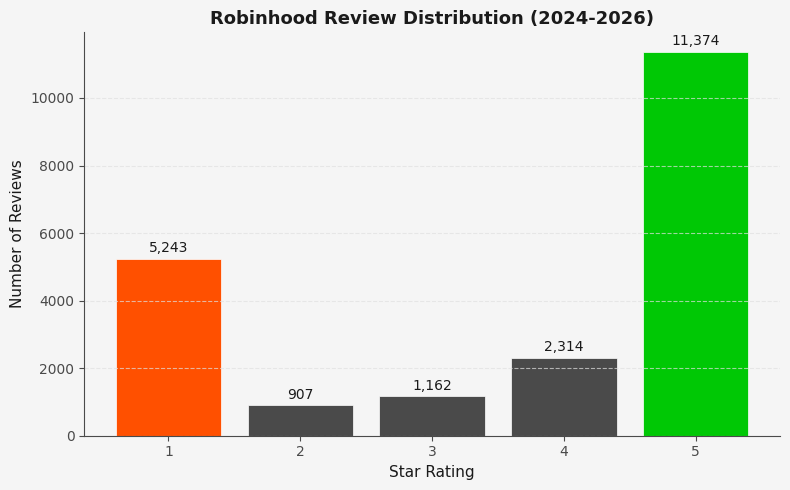

Average rating: 3.65


In [5]:
# Counting how many reviews fall into each star rating (1 through 5)
score_counts = df['score'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

bar_colors = [RH_RED, RH_GRAY, RH_GRAY, RH_GRAY, RH_GREEN]
bars = ax.bar(score_counts.index, score_counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)

# Adding count labels on top of each bar so the numbers are easy to read
for bar, count in zip(bars, score_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}', ha='center', va='bottom', fontsize=10, color=RH_DARK)

ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_title('Robinhood Review Distribution (2024-2026)', fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(f'Average rating: {df["score"].mean():.2f}')

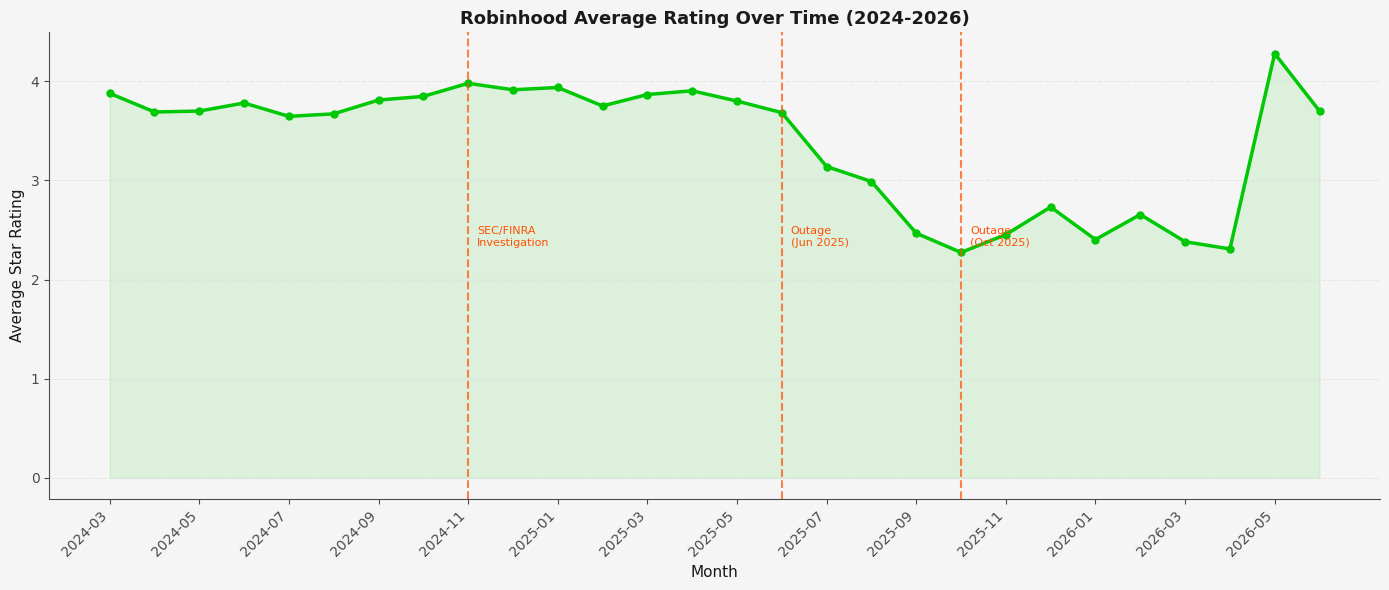

In [6]:
# Extracting year-month from the full timestamp so we can group by month
df['month'] = df['at'].dt.to_period('M')

# Grouping all reviews by month and calculating the average star rating for that month
monthly_score = df.groupby('month')['score'].mean()
monthly_count = df.groupby('month')['score'].count()

# Key events to overlay on the chart
key_events = {
    '2024-11': 'SEC/FINRA\nInvestigation',
    '2025-06': 'Outage\n(Jun 2025)',
    '2025-10': 'Outage\n(Oct 2025)',
}

fig, ax = plt.subplots(figsize=(14, 6))

# Plotting the monthly average rating as a line
ax.plot(monthly_score.index.astype(str), monthly_score.values,
        color=RH_GREEN, linewidth=2.5, marker='o', markersize=5, label='Avg Rating')

ax.fill_between(range(len(monthly_score)), monthly_score.values,
                alpha=0.1, color=RH_GREEN)

months_list = monthly_score.index.astype(str).tolist()
for event_month, label in key_events.items():
    if event_month in months_list:
        idx = months_list.index(event_month)
        ax.axvline(x=idx, color=RH_RED, linestyle='--', alpha=0.7, linewidth=1.5)
        ax.text(idx + 0.2, monthly_score.min() + 0.05, label,
                fontsize=8, color=RH_RED, va='bottom')

ax.set_xlabel('Month')
ax.set_ylabel('Average Star Rating')
ax.set_title('Robinhood Average Rating Over Time (2024-2026)', fontweight='bold')
ax.set_xticks(range(0, len(monthly_score), 2))
ax.set_xticklabels(months_list[::2], rotation=45, ha='right')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

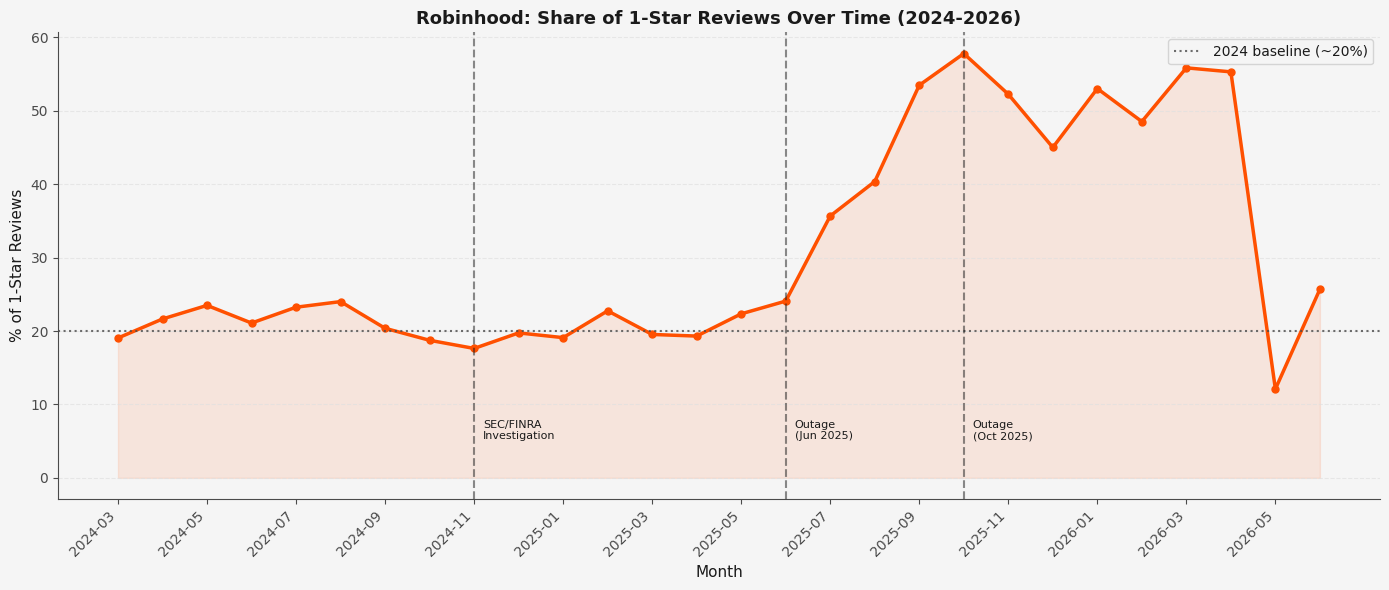

In [7]:
# Calculating what percentage of each month's reviews are 1-star

total_per_month = df.groupby('month')['score'].count()
one_star_per_month = df[df['score'] == 1].groupby('month')['score'].count()
one_star_pct = (one_star_per_month / total_per_month * 100).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(one_star_pct.index.astype(str), one_star_pct.values,
        color=RH_RED, linewidth=2.5, marker='o', markersize=5)

# Shading the area under the line
ax.fill_between(range(len(one_star_pct)), one_star_pct.values, alpha=0.1, color=RH_RED)

ax.axhline(y=20, color=RH_GRAY, linestyle=':', alpha=0.8, linewidth=1.5, label='2024 baseline (~20%)')

months_list = one_star_pct.index.astype(str).tolist()
for event_month, label in key_events.items():
    if event_month in months_list:
        idx = months_list.index(event_month)
        ax.axvline(x=idx, color=RH_DARK, linestyle='--', alpha=0.5, linewidth=1.5)
        ax.text(idx + 0.2, 5, label, fontsize=8, color=RH_DARK, va='bottom')

ax.set_xlabel('Month')
ax.set_ylabel('% of 1-Star Reviews')
ax.set_title('Robinhood: Share of 1-Star Reviews Over Time (2024-2026)', fontweight='bold')
ax.set_xticks(range(0, len(one_star_pct), 2))
ax.set_xticklabels(months_list[::2], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### 5. Sentiment Analysis
*Using VADER (Valence Aware Dictionary and sEntiment Reasoner) to score each review.*
*VADER is specifically designed for short, informal text like app reviews.*

> **Limitation:** VADER cannot detect sarcasm. Phrases like 'great app, love losing money' score as positive. Because of this, we use star ratings as the primary signal and VADER as supplementary.

In [8]:
analyzer = SentimentIntensityAnalyzer()

# The compound score ranges from -1.0 (most negative) to +1.0 (most positive)
# We apply it to every review in the content column
df['sentiment_score'] = df['content'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Labelling each review based on its compound score
# Below -0.05 = negative, above 0.05 = positive, in between = neutral
df['sentiment_label'] = df['sentiment_score'].apply(
    lambda x: 'Negative' if x < -0.05 else ('Positive' if x > 0.05 else 'Neutral')
)

# Results
counts = df['sentiment_label'].value_counts()
pcts = (counts / len(df) * 100).round(1)
for label in ['Positive', 'Neutral', 'Negative']:
    print(f'{label}: {counts[label]:,} reviews ({pcts[label]}%)')

Positive: 13,902 reviews (66.2%)
Neutral: 2,950 reviews (14.0%)
Negative: 4,148 reviews (19.8%)


### 6. Negative Review Deep Dive
*Focusing on 1-star reviews to understand what users are actually complaining about.*

In [9]:
# Filtering to 1-star reviews only and remove any empty reviews
negative_reviews = df[df['score'] == 1]['content'].dropna()
negative_reviews = negative_reviews[negative_reviews.str.strip() != '']

print(f'Total 1-star reviews for analysis: {len(negative_reviews):,}')
print('\n--- Sample of 5 negative reviews ---\n')
for review in negative_reviews.sample(5, random_state=42):
    print(f'>> {review[:200]}')
    print()

Total 1-star reviews for analysis: 5,242

--- Sample of 5 negative reviews ---

>> this app seems to have taken over every time I click on something this pops up and wants me to download it I don't want it I don't need it I can't stop it what's wrong.

>> I applied for the gold card when it was first announce been on waiting list til now...2025 is almost here. Contacted customer service numerous time ...THEY JUST KEEP SAYING WAIT...they are totally wor

>> won't allow me to access my account because I dont have my old phone number is wild gladly I didnt invest into any of those stocks money would of taken I guess

>> Check price change for HOOD stock and you will know where they are going with their investers money. When i buy stocks, the stock price goes down, they seem to copy successful traders on their app. Go

>> Won't open up



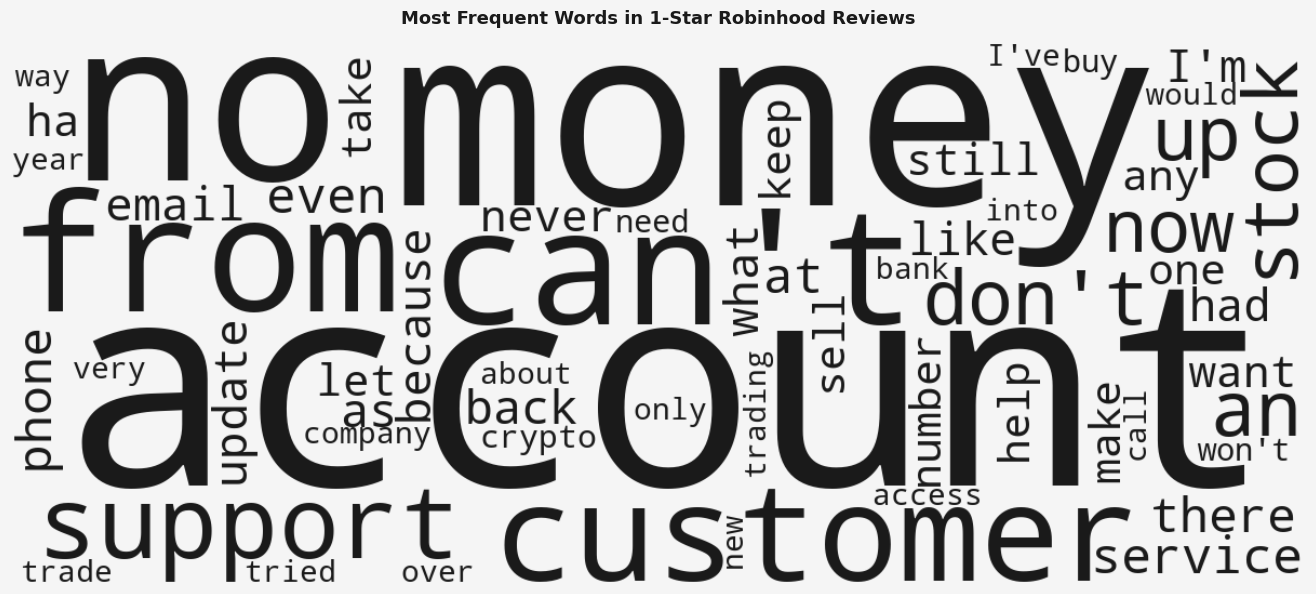

In [10]:
# Word cloud of the most common words in 1-star reviews
# We remove generic words (stopwords) that don't add meaning

text = ' '.join(negative_reviews)

custom_stopwords = {
    'robinhood', 'app', 'just', 'don', 'use', 'will', 'get',
    'the', 'and', 'it', 'this', 'that', 'for', 'not', 'my',
    'they', 'you', 'have', 'with', 'but', 'all', 'can', 'so',
    'or', 'are', 'your', 'their', 'out', 'do', 'be', 'when',
    'in', 'to', 'of', 'a', 'i', 'me', 'is', 'on', 'if', 'after',
    'then', 'them', 'was', 'been', 'time', 'day', 'trying', 'cant'
}

wordcloud = WordCloud(
    width=1200,
    height=500,
    background_color=RH_LIGHT,
    color_func=lambda *args, **kwargs: RH_DARK,  # All words in dark color
    stopwords=custom_stopwords,
    max_words=60,
    collocations=False
).generate(text)

fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words in 1-Star Robinhood Reviews', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [11]:
# Checking how often users mention switching to a competitor
# Low overall % is expected - most users don't explicitly say they're switching
# But the split between which competitors tells us WHO is leaving

competitors = ['fidelity', 'schwab', 'webull', 'etrade', 'td ameritrade', 'charles schwab']

df['competitor_mention'] = df['content'].str.lower().apply(
    lambda x: any(c in str(x) for c in competitors)
)

print(f'Reviews mentioning a competitor: {df["competitor_mention"].sum():,} ({df["competitor_mention"].mean()*100:.1f}% of all reviews)')
print()
for c in competitors:
    count = df['content'].str.lower().str.contains(c).sum()
    print(f'  {c.title()}: {count} mentions')

Reviews mentioning a competitor: 262 (1.2% of all reviews)

  Fidelity: 98 mentions
  Schwab: 51 mentions
  Webull: 110 mentions
  Etrade: 22 mentions
  Td Ameritrade: 6 mentions
  Charles Schwab: 11 mentions


### 7. LDA Topic Modeling
*Instead of manually guessing complaint categories, we let the algorithm find them.*
*LDA (Latent Dirichlet Allocation) reads all 5,000+ negative reviews and groups them into topics based on which words tend to appear together. This is more rigorous than a word cloud because it finds **meaning clusters**, not just frequency.*

In [12]:
# Words we want to exclude from topic modeling
# These are either too generic or too specific to Robinhood's name to add signal
custom_stopwords_lda = STOPWORDS.union({
    'robinhood', 'app', 'just', 'use', 'get', 'got', 'like',
    'really', 'even', 'know', 'think', 'want', 'going', 'said',
    'say', 'way', 'time', 'now', 'still', 'back', 'ever', 'never'
})

def preprocess(text):
    return [word for word in simple_preprocess(str(text))
            if word not in custom_stopwords_lda and len(word) > 3]

# Applying preprocessing to all 1-star reviews
processed_reviews = [preprocess(review) for review in negative_reviews]

# Building a dictionary mapping every unique word to an ID number
dictionary = corpora.Dictionary(processed_reviews)

# Removing words that appear in fewer than 5 reviews (too rare) or more than 50% of reviews (too common to be meaningful)
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Converting each review to bag-of-words format: (word_id, frequency) pairs
corpus = [dictionary.doc2bow(review) for review in processed_reviews]

print(f'Vocabulary size: {len(dictionary):,} unique meaningful words')
print(f'Reviews processed: {len(corpus):,}')

Vocabulary size: 1,761 unique meaningful words
Reviews processed: 5,242


In [13]:
# Training the LDA model
# num_topics=5 because we identified 5 complaint categories in our hypothesis
# passes=10 means the model reads through all reviews 10 times to improve accuracy
# random_state=42 makes results reproducible every time we run this

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42
)

# Human-readable labels we assign to each topic based on top words
topic_labels = {
    0: 'Account Access',
    1: 'Customer Service',
    2: 'Churn Intent',
    3: 'Financial Trust',
    4: 'Trading Experience'
}

print('Top words per topic:')
for idx, topic in lda_model.print_topics(num_words=6):
    print(f'  Topic {idx} ({topic_labels[idx]}): {topic}')

Top words per topic:
  Topic 0 (Account Access): 0.093*"account" + 0.025*"support" + 0.022*"customer" + 0.016*"help" + 0.016*"service" + 0.015*"money"
  Topic 1 (Customer Service): 0.037*"phone" + 0.029*"account" + 0.026*"number" + 0.025*"update" + 0.020*"email" + 0.014*"support"
  Topic 2 (Churn Intent): 0.110*"money" + 0.024*"scam" + 0.012*"transfer" + 0.012*"account" + 0.011*"sell" + 0.010*"days"
  Topic 3 (Financial Trust): 0.028*"stock" + 0.022*"stocks" + 0.021*"trading" + 0.019*"sell" + 0.017*"crypto" + 0.016*"market"
  Topic 4 (Trading Experience): 0.037*"account" + 0.036*"customer" + 0.032*"service" + 0.020*"card" + 0.019*"money" + 0.019*"bank"


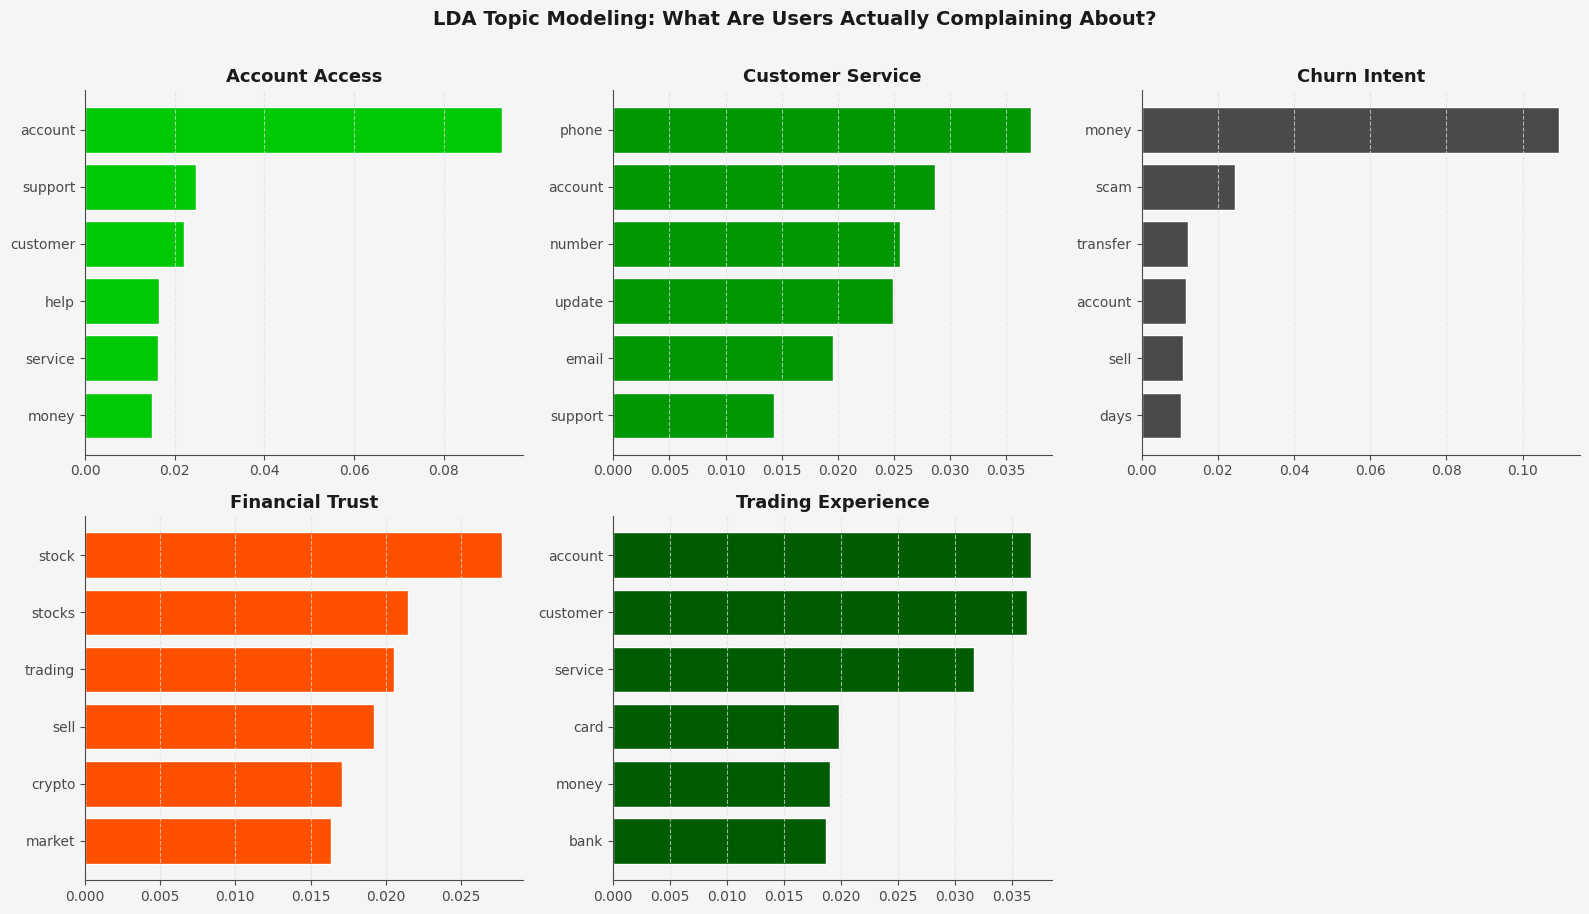

In [14]:
# Visualizing top words for each topic as horizontal bar charts
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

topic_colors = [RH_GREEN, RH_GREEN_DARK, RH_GRAY, RH_RED, '#005C02']

for idx in range(5):
    top_words = dict(lda_model.show_topic(idx, topn=6))
    words = list(top_words.keys())
    weights = list(top_words.values())

    axes[idx].barh(words, weights, color=topic_colors[idx], edgecolor='white')
    axes[idx].set_title(f'{topic_labels[idx]}', fontweight='bold')
    axes[idx].invert_yaxis()
    axes[idx].grid(axis='x')

axes[5].set_visible(False)

fig.suptitle('LDA Topic Modeling: What Are Users Actually Complaining About?',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8. Topic Trends Over Time
*Assigning each 1-star review its dominant topic and tracking how complaint categories change month by month. This links our complaint categories to real-world events.*

In [15]:
def get_dominant_topic(bow):
    # For each review, find the topic it belongs to most strongly
    # get_document_topics returns (topic_id, probability) pairs
    # we pick the one with the highest probability
    topics = lda_model.get_document_topics(bow)
    if topics:
        return max(topics, key=lambda x: x[1])[0]
    return None

# Applying to all 1-star reviews
dominant_topics = [get_dominant_topic(bow) for bow in corpus]

# Adding topic assignments back to a filtered copy of the dataframe
one_star_df = df[df['score'] == 1].dropna(subset=['content']).copy()
one_star_df['dominant_topic'] = dominant_topics
one_star_df['topic_label'] = one_star_df['dominant_topic'].map(topic_labels)
one_star_df['month'] = pd.to_datetime(one_star_df['at']).dt.to_period('M')

print('Reviews per topic:')
print(one_star_df['topic_label'].value_counts().to_string())

Reviews per topic:
topic_label
Customer Service      1295
Financial Trust       1203
Account Access        1036
Churn Intent           938
Trading Experience     770


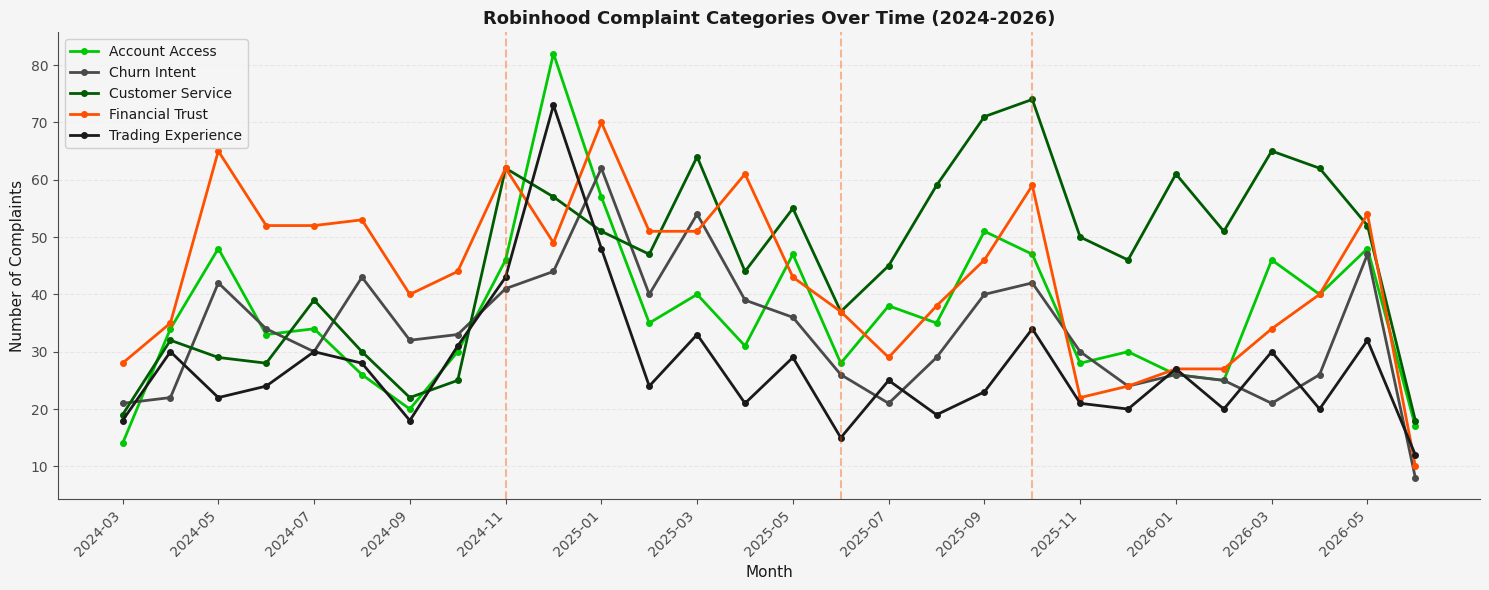

In [16]:
# Counting reviews per topic per month to build a time series
topic_trend = one_star_df.groupby(['month', 'topic_label']).size().unstack(fill_value=0)

line_colors = {
    'Account Access': RH_GREEN,
    'Customer Service': '#005C02',
    'Churn Intent': RH_GRAY,
    'Financial Trust': RH_RED,
    'Trading Experience': RH_DARK
}

fig, ax = plt.subplots(figsize=(15, 6))

for topic in topic_trend.columns:
    ax.plot(topic_trend.index.astype(str), topic_trend[topic],
            marker='o', markersize=4, linewidth=2,
            color=line_colors.get(topic, RH_GRAY), label=topic)

# Adding event markers
months_list = topic_trend.index.astype(str).tolist()
for event_month, label in key_events.items():
    if event_month in months_list:
        idx = months_list.index(event_month)
        ax.axvline(x=idx, color=RH_RED, linestyle='--', alpha=0.4, linewidth=1.5)

ax.set_xlabel('Month')
ax.set_ylabel('Number of Complaints')
ax.set_title('Robinhood Complaint Categories Over Time (2024-2026)', fontweight='bold')
ax.set_xticks(range(0, len(topic_trend), 2))
ax.set_xticklabels(months_list[::2], rotation=45, ha='right')
ax.legend(loc='upper left', framealpha=0.9)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### 9. Thumbs Up Weighted Analysis
*Not all complaints are equal. A review with 500 thumbs up represents hundreds of users who felt the same way. Weighting by thumbs up surfaces the most **resonant** complaints, not just the most frequent ones.*

In [17]:
# Showing the 10 most upvoted negative reviews with their topics
top_thumbs = one_star_df.nlargest(10, 'thumbsUpCount')[
    ['content', 'thumbsUpCount', 'at', 'topic_label']
]

print('Top 10 Most Community-Validated Complaints:\n')
for _, row in top_thumbs.iterrows():
    print(f'  {row["thumbsUpCount"]} thumbs up | {row["topic_label"]} | {row["at"].date()}')
    print(f'  "{str(row["content"])[:180]}"')
    print()

Top 10 Most Community-Validated Complaints:

  834 thumbs up | Churn Intent | 2024-08-13
  "Please do not waste your time or money with this app! No such thing as "no fees"."

  616 thumbs up | Customer Service | 2025-10-08
  "Robinhood app crashes if I'm on option simulated returns for more than a few seconds."

  530 thumbs up | Financial Trust | 2026-02-26
  "your app is broken. I can't put in any orders to buy stocks or crypto... the keyboard to put in an order doesn't come up no matter what I do. you broke your app..."

  443 thumbs up | Customer Service | 2024-05-25
  "Absolutely hate that I'm forced to use dark theme for all crypto. At that point why even pretend to let us customize our theme?"

  442 thumbs up | Financial Trust | 2026-04-22
  "The app sets you up for failure by inducing its users to make mistakes. UPDATE: app got worse, when creating a new order the app is intentionally deleting the digits when trying to"

  409 thumbs up | Trading Experience | 2025-05-14
  "We

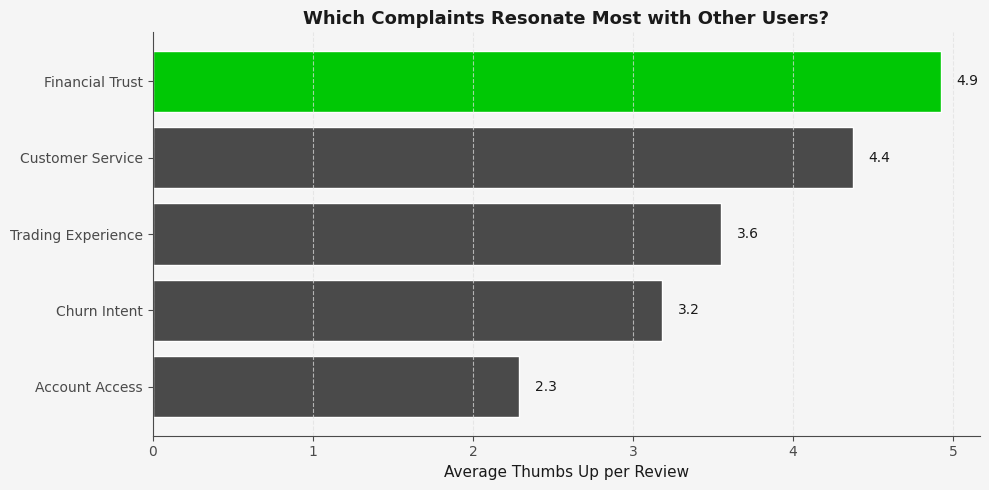

In [19]:
# Calculating average thumbs up per topic
# This tells us which complaint category resonates most broadly with users
thumbs_by_topic = one_star_df.groupby('topic_label')['thumbsUpCount'].agg(
    total_thumbs='sum',
    avg_thumbs='mean',
    review_count='count'
).sort_values('avg_thumbs', ascending=True)  # ascending for horizontal bar chart

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [RH_GRAY] * len(thumbs_by_topic)
bar_colors[-1] = RH_GREEN  # Last bar (highest) gets green

bars = ax.barh(thumbs_by_topic.index, thumbs_by_topic['avg_thumbs'],
               color=bar_colors, edgecolor='white')

# Adding value labels at the end of each bar
for bar, val in zip(bars, thumbs_by_topic['avg_thumbs']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, color=RH_DARK)

ax.set_xlabel('Average Thumbs Up per Review')
ax.set_title('Which Complaints Resonate Most with Other Users?', fontweight='bold')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

### 10. Product Priority Matrix
*Plotting each complaint category on two axes:*
- ***X axis (Volume):** How many reviews belong to this topic*
- ***Y axis (Resonance):** Average thumbs up per review*

*This turns our analysis into an actionable prioritization framework for PMs.*

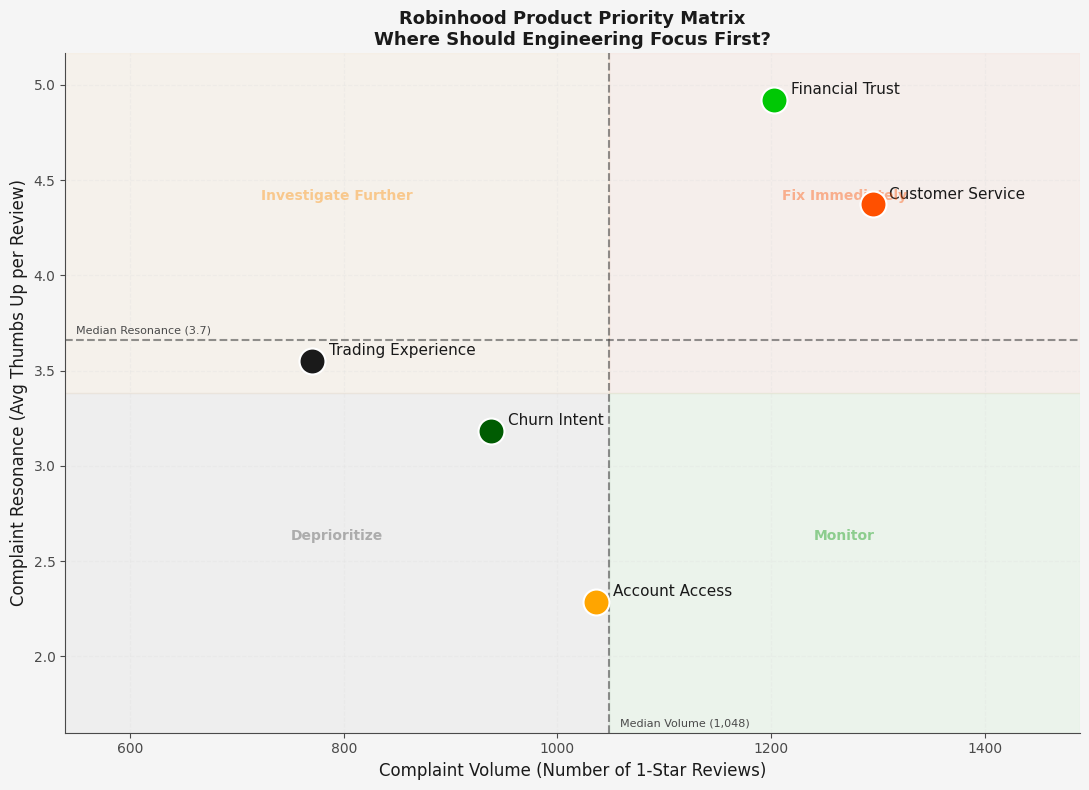

In [22]:
# Re-sorting by avg_thumbs descending for the matrix
thumbs_by_topic = thumbs_by_topic.sort_values('avg_thumbs', ascending=False)

topics = thumbs_by_topic.index.tolist()
x = thumbs_by_topic['review_count'].tolist()   # Volume on X axis
y = thumbs_by_topic['avg_thumbs'].tolist()     # Resonance on Y axis

# Calculating median lines that divide the chart into 4 quadrants
median_x = sum(x) / len(x)
median_y = sum(y) / len(y)

fig, ax = plt.subplots(figsize=(11, 8))

# Quadrant background shading to make regions visually distinct
ax.axvspan(median_x, max(x)*1.15, ymin=0.5, ymax=1.0, alpha=0.04, color=RH_RED)
ax.axvspan(0, median_x, ymin=0.5, ymax=1.0, alpha=0.04, color='orange')
ax.axvspan(median_x, max(x)*1.15, ymin=0, ymax=0.5, alpha=0.04, color=RH_GREEN)
ax.axvspan(0, median_x, ymin=0, ymax=0.5, alpha=0.04, color=RH_GRAY)

# Quadrant divider lines
ax.axvline(x=median_x, color=RH_GRAY, linestyle='--', alpha=0.6, linewidth=1.5)
ax.axhline(y=median_y, color=RH_GRAY, linestyle='--', alpha=0.6, linewidth=1.5)

# Plotting each topic as a dot
dot_colors = [RH_GREEN, RH_RED, RH_DARK, '#005C02', 'orange']
for i, topic in enumerate(topics):
    ax.scatter(x[i], y[i], s=350, color=dot_colors[i], zorder=5,
               edgecolors='white', linewidth=1.5)
    ax.annotate(topic, (x[i], y[i]),
                textcoords='offset points', xytext=(12, 4), fontsize=11)

# Quadrant labels
# Calculate axis limits first so we can position labels correctly
x_min, x_max = min(x) * 0.7, max(x) * 1.15
y_min, y_max = min(y) * 0.7, max(y) * 1.05

# Position labels in the CENTER of each quadrant
# Top-right quadrant: x between median and max, y between median and max
ax.text((median_x + x_max) / 2, (median_y + y_max) / 2, 'Fix Immediately',
        fontsize=10, color=RH_RED, fontweight='bold', ha='center', va='center', alpha=0.4)

# Top-left quadrant
ax.text((x_min + median_x) / 2, (median_y + y_max) / 2, 'Investigate Further',
        fontsize=10, color='darkorange', fontweight='bold', ha='center', va='center', alpha=0.4)

# Bottom-right quadrant
ax.text((median_x + x_max) / 2, (y_min + median_y) / 2, 'Monitor',
        fontsize=10, color=RH_GREEN_DARK, fontweight='bold', ha='center', va='center', alpha=0.4)

# Bottom-left quadrant
ax.text((x_min + median_x) / 2, (y_min + median_y) / 2, 'Deprioritize',
        fontsize=10, color=RH_GRAY, fontweight='bold', ha='center', va='center', alpha=0.4)

# Set axis limits explicitly so nothing gets cut off
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Reference line labels sitting just above/right of the median lines
ax.text(median_x + 10, y_min + 0.02, f'Median Volume ({int(median_x):,})',
        fontsize=8, color=RH_GRAY, va='bottom')
ax.text(x_min + 10, median_y + 0.02, f'Median Resonance ({median_y:.1f})',
        fontsize=8, color=RH_GRAY, va='bottom')

ax.set_xlabel('Complaint Volume (Number of 1-Star Reviews)', fontsize=12)
ax.set_ylabel('Complaint Resonance (Avg Thumbs Up per Review)', fontsize=12)
ax.set_title('Robinhood Product Priority Matrix\nWhere Should Engineering Focus First?',
             fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 11. Key Findings Summary

| Finding | Evidence |
|---|---|
| Sentiment collapsed mid-2025 and never recovered | 1-star % jumped from ~20% to 55%+ |
| Two outages explain the collapse | Jun 13 and Oct 6, 2025 confirmed outages |
| Regulatory actions damaged trust before outages | SEC/FINRA $45M penalty building in Q4 2024 |
| Trading Experience is most validated complaint | 6.4 avg thumbs up vs 3.0 for next category |
| Users leaving in two directions | Webull (110 mentions) and Fidelity (98 mentions) |

***Central thesis:** Robinhood's trading reliability failures are the primary driver of trust collapse. Every major validated complaint involves losing real money because the app failed at the moment of a trade.*

***Recommendation:** Rebuild the order placement flow as a reliability-first experience with a stripped-down Reliability Mode during high-volatility periods and explicit order confirmation safeguards.*

---
*Ruchira Lokhande | github.com/ruchirarl*